In [29]:
import torch

micro_unc = torch.load(
    "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/an_embedding_active_learning/embeddings_micro/micro_level_uncertainty_scores.pt"
)
meso_unc = torch.load(
    "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/an_embedding_active_learning/meso_uncertainty_scores.pt"
)




In [30]:
meso_unc = torch.load(
    "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/an_embedding_active_learning/meso_uncertainty_scores.pt"
)

for i in range(5):
    fname = meso_unc["filenames"][i]
    maxu = meso_unc["uncertainty_max"][i]
    topk = meso_unc["uncertainty_topk"][i]
    entropy = meso_unc["uncertainty_entropy"][i]
    gcnu = meso_unc["uncertainty_gcnu"][i]
    mmd = meso_unc["uncertainty_mmd"][i]
    wass = meso_unc["uncertainty_wasserstein"][i]
    wasspca = meso_unc["uncertainty_wasserstein_pca"][i]
    print(f"{fname}: max={maxu:.4f}, topk={topk:.4f}, entropy={entropy:.4f}, gcnu={gcnu:.4f}, mmd={mmd:.4f}, wass={wass:.4f}, wasspca={wasspca:.4f}")


8988385_3096614_x384_y0_crop9075.png: max=0.0514, topk=0.0572, entropy=8.1523, gcnu=0.0536, mmd=0.9421, wass=593.8139, wasspca=3.0463
9024157_3110373_x128_y128_crop8965.png: max=0.0401, topk=0.0420, entropy=8.1507, gcnu=0.0412, mmd=0.8734, wass=568.0939, wasspca=2.9516
9010399_3126883_x0_y384_crop2300.png: max=0.0660, topk=0.0716, entropy=8.1614, gcnu=0.0699, mmd=0.9836, wass=573.0128, wasspca=3.2331
8993888_3093862_x128_y384_crop3133.png: max=0.0480, topk=0.0536, entropy=8.1527, gcnu=0.0502, mmd=0.9386, wass=591.1797, wasspca=2.9829
9002144_3126883_x384_y128_crop4119.png: max=0.1649, topk=0.1673, entropy=8.1766, gcnu=0.1800, mmd=1.0478, wass=552.1333, wasspca=4.2131


In [31]:
micro_unc = torch.load(
    "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/an_embedding_active_learning/micro_uncertainty_scores.pt"
)
print(list(micro_unc.keys()))

for i in range(5):
    fname = micro_unc["filenames"][i]
    maxu = micro_unc["uncertainty_max"][i]
    topk = micro_unc["uncertainty_topk"][i]
    entropy = micro_unc["uncertainty_entropy"][i]
    gcnu = micro_unc["uncertainty_gcnu"][i]
    mmd = micro_unc["uncertainty_mmd"][i]
    wass = micro_unc["uncertainty_wasserstein"][i]
    wasspca = micro_unc["uncertainty_wasserstein_pca"][i]
    print(f"{fname}: max={maxu:.4f}, topk={topk:.4f}, entropy={entropy:.4f}, gcnu={gcnu:.4f}, mmd={mmd:.4f}, wass={wass:.4f}, wasspca={wasspca:.4f}")

['filenames', 'uncertainty_max', 'uncertainty_topk', 'uncertainty_margin', 'uncertainty_entropy', 'uncertainty_gcnu', 'uncertainty_mmd', 'uncertainty_wasserstein', 'uncertainty_wasserstein_pca']
8980130_3077352_x0_y0_crop37700.png: max=0.1531, topk=0.1676, entropy=8.3215, gcnu=0.1712, mmd=1.0030, wass=212.3172, wasspca=2.2167
8980130_3077352_x0_y128_crop37720.png: max=0.0833, topk=0.0919, entropy=8.3175, gcnu=0.0878, mmd=0.9643, wass=211.5526, wasspca=2.7916
8980130_3077352_x0_y192_crop37730.png: max=0.1094, topk=0.1195, entropy=8.3189, gcnu=0.1211, mmd=0.9511, wass=192.3146, wasspca=2.4916
8980130_3077352_x0_y256_crop37740.png: max=0.0924, topk=0.0991, entropy=8.3207, gcnu=0.1000, mmd=0.9133, wass=151.6047, wasspca=2.0506
8980130_3077352_x0_y320_crop37750.png: max=0.0898, topk=0.1005, entropy=8.3206, gcnu=0.0991, mmd=0.9009, wass=147.0939, wasspca=2.0598


In [32]:
import torch
import pandas as pd

# Micro uncertainty (all metrics)
micro_unc = torch.load(
    "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/an_embedding_active_learning/micro_uncertainty_scores.pt"
)
micro_df = pd.DataFrame({
    "filename": micro_unc["filenames"],
    "micro_wass": micro_unc["uncertainty_wasserstein"],
})

# Meso uncertainty (Wasserstein only)
meso_unc = torch.load(
    "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/an_embedding_active_learning/meso_uncertainty_scores.pt"
)
meso_df = pd.DataFrame({
    "filename": meso_unc["filenames"],
    "meso_wass": meso_unc["uncertainty_wasserstein"],
})


In [33]:
df = pd.merge(micro_df, meso_df, on="filename", how="inner")
print(f"{len(df)} samples with both micro and meso Wasserstein scores.")


1 samples with both micro and meso Wasserstein scores.


In [34]:
print(micro_df["filename"].head(10))
print(meso_df["filename"].head(10))


0      8980130_3077352_x0_y0_crop37700.png
1    8980130_3077352_x0_y128_crop37720.png
2    8980130_3077352_x0_y192_crop37730.png
3    8980130_3077352_x0_y256_crop37740.png
4    8980130_3077352_x0_y320_crop37750.png
5    8980130_3077352_x0_y384_crop37760.png
6    8980130_3077352_x0_y448_crop37770.png
7    8980130_3077352_x0_y512_crop37780.png
8    8980130_3077352_x0_y576_crop37790.png
9     8980130_3077352_x0_y64_crop37710.png
Name: filename, dtype: object
0      8988385_3096614_x384_y0_crop9075.png
1    9024157_3110373_x128_y128_crop8965.png
2      9010399_3126883_x0_y384_crop2300.png
3    8993888_3093862_x128_y384_crop3133.png
4    9002144_3126883_x384_y128_crop4119.png
5     8985633_3146145_x384_y256_crop475.png
6    9002144_3146145_x384_y128_crop7383.png
7      8988385_3113124_x0_y128_crop1364.png
8    9013151_3091111_x384_y256_crop4427.png
9        9032413_3126883_x0_y0_crop3376.png
Name: filename, dtype: object


In [35]:
import re

def extract_center(fname):
    # e.g. 8980130_3077352_x0_y0_crop37700.png
    m = re.search(r'(\d+_\d+)_x(\d+)_y(\d+)', fname)
    if m:
        imgid, x, y = m.groups()
        return imgid, int(x), int(y)
    else:
        return None, None, None

micro_df[["imgid", "x", "y"]] = micro_df["filename"].apply(
    lambda f: pd.Series(extract_center(f))
)
meso_df[["imgid", "x", "y"]] = meso_df["filename"].apply(
    lambda f: pd.Series(extract_center(f))
)

df = pd.merge(
    micro_df,
    meso_df,
    on=["imgid", "x", "y"],
    how="inner",
    suffixes=("_micro", "_meso")
)
print(f"{len(df)} patches aligned by spatial center.")


9568 patches aligned by spatial center.


In [36]:
alpha = 0.7  # weight for micro
beta = 0.3   # weight for meso

df["H-Uncertainty"] = (df["micro_wass"] ** alpha) * (df["meso_wass"] ** beta)


In [37]:
N = 100  # how many to select for labeling
df = df.sort_values("H-Uncertainty", ascending=False)
from IPython.display import display
display(df.head(10))

df = df.sort_values("H-Uncertainty", ascending=False)
#make my display more readable and looking nice code



selected = df.head(N).reset_index(drop=True)
print(f"Selected {len(selected)} patches with highest H-Uncertainty scores.")

# selected["filename"].to_csv("hgcnu_selected_lucknow_micro_centers.csv", index=False)
print(selected[["imgid", "H-Uncertainty"]].head())
selected[["imgid", "H-Uncertainty"]].to_csv("lucknow_hgcnu_selected.csv", index=False)
print("Selected patches saved to lucknow_hgcnu_selected.csv")


,filename_micro,micro_wass,imgid,x,y,filename_meso,meso_wass,H-Uncertainty
5706,9015902_3126883_x256_y256_crop14144.png,618.790771,9015902_3126883,256,256,9015902_3126883_x256_y256_crop2266.png,575.634766,605.514830
6852,9024157_3110373_x128_y0_crop56002.png,552.730225,9024157_3110373,128,0,9024157_3110373_x128_y0_crop8961.png,540.013489,548.884077
5480,9015902_3088359_x256_y0_crop44004.png,486.128021,9015902_3088359,256,0,9015902_3088359_x256_y0_crop7042.png,621.519775,523.313507
4559,9007647_3143393_x384_y384_crop4266.png,444.616730,9007647_3143393,384,384,9007647_3143393_x384_y384_crop687.png,611.251099,489.165654
7672,9029661_3107621_x256_y0_crop5304.png,431.697021,9029661_3107621,256,0,9029661_3107621_x256_y0_crop850.png,647.411560,487.505446
9359,9040668_3110373_x384_y384_crop8266.png,368.638550,9040668_3110373,384,384,9040668_3110373_x384_y384_crop1327.png,819.518005,468.476785
5457,9015902_3085607_x0_y128_crop35320.png,422.040985,9015902_3085607,0,128,9015902_3085607_x0_y128_crop5652.png,588.798157,466.378125
1605,8988385_3137890_x128_y128_crop52222.png,342.545959,8988385_3137890,128,128,8988385_3137890_x128_y128_crop8357.png,915.397217,460.029911
5961,9018654_3099366_x256_y128_crop19324.png,412.542206,9018654_3099366,256,128,9018654_3099366_x256_y128_crop3094.png,591.042236,459.529531
4435,9007647_3124131_x0_y384_crop24260.png,419.261627,9007647_3124131,0,384,9007647_3124131_x0_y384_crop3884.png,559.302734,457.123621


Selected 100 patches with highest H-Uncertainty scores.
             imgid  H-Uncertainty
0  9015902_3126883     605.514830
1  9024157_3110373     548.884077
2  9015902_3088359     523.313507
3  9007647_3143393     489.165654
4  9029661_3107621     487.505446
Selected patches saved to lucknow_hgcnu_selected.csv


In [42]:
import pandas as pd
from IPython.display import display

# Parameters
N = 100  # number of patches to select
alpha = 0.7  # micro weight
beta = 0.3   # meso weight

# Compute H-Uncertainty
df["H-Uncertainty"] = (df["micro_wass"] ** alpha) * (df["meso_wass"] ** beta)

# Sort by H-Uncertainty
df = df.sort_values("H-Uncertainty", ascending=False)

# Display top 10 with styling
styled_top10 = df[["imgid","filename_micro", "micro_wass", "filename_meso", "meso_wass", "H-Uncertainty"]].head(10).style \
    .background_gradient(cmap='Reds', subset=["H-Uncertainty"]) \
    .format(precision=4) \
    .set_caption("🔍 Top 10 Patches by H-Uncertainty")

display(styled_top10)

# Select top N
selected = df.head(N).reset_index(drop=True)
print(f"✅ Selected {len(selected)} patches with highest H-Uncertainty scores.")

# Save results
selected[["imgid", "H-Uncertainty"]].to_csv("lucknow_hgcnu_selected.csv", index=False)
print("💾 Selected patches saved to `lucknow_hgcnu_selected.csv`")

# Preview top 5 selected
display(selected[["imgid", "H-Uncertainty"]].head().style.format(precision=4))


,imgid,filename_micro,micro_wass,filename_meso,meso_wass,H-Uncertainty
5706,9015902_3126883,9015902_3126883_x256_y256_crop14144.png,618.7908,9015902_3126883_x256_y256_crop2266.png,575.6348,605.5148
6852,9024157_3110373,9024157_3110373_x128_y0_crop56002.png,552.7302,9024157_3110373_x128_y0_crop8961.png,540.0135,548.8841
5480,9015902_3088359,9015902_3088359_x256_y0_crop44004.png,486.1280,9015902_3088359_x256_y0_crop7042.png,621.5198,523.3135
4559,9007647_3143393,9007647_3143393_x384_y384_crop4266.png,444.6167,9007647_3143393_x384_y384_crop687.png,611.2511,489.1657
7672,9029661_3107621,9029661_3107621_x256_y0_crop5304.png,431.6970,9029661_3107621_x256_y0_crop850.png,647.4116,487.5054
9359,9040668_3110373,9040668_3110373_x384_y384_crop8266.png,368.6385,9040668_3110373_x384_y384_crop1327.png,819.5180,468.4768
5457,9015902_3085607,9015902_3085607_x0_y128_crop35320.png,422.0410,9015902_3085607_x0_y128_crop5652.png,588.7982,466.3781
1605,8988385_3137890,8988385_3137890_x128_y128_crop52222.png,342.5460,8988385_3137890_x128_y128_crop8357.png,915.3972,460.0299
5961,9018654_3099366,9018654_3099366_x256_y128_crop19324.png,412.5422,9018654_3099366_x256_y128_crop3094.png,591.0422,459.5295
4435,9007647_3124131,9007647_3124131_x0_y384_crop24260.png,419.2616,9007647_3124131_x0_y384_crop3884.png,559.3027,457.1236


✅ Selected 100 patches with highest H-Uncertainty scores.
💾 Selected patches saved to `lucknow_hgcnu_selected.csv`


,imgid,H-Uncertainty
0,9015902_3126883,605.5148
1,9024157_3110373,548.8841
2,9015902_3088359,523.3135
3,9007647_3143393,489.1657
4,9029661_3107621,487.5054


In [1]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from torchvision.models import ResNet50_Weights
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone

In [2]:
# Paths
base_line_image_dir = '/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/staclip/delhi_airshed/images'
base_line_label_dir = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/staclip/delhi_airshed/labels_voc"
image_dir = '/home/umang.shikarvar/Final/lucknow_airshed/val/images'
label_dir = '/home/umang.shikarvar/Final/lucknow_airshed/val/labels'
save_path = '/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/staclip/lucknow_airshed/save'
hunc_file = '/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/an_embedding_active_learning/lucknow_hgcnu_selected.csv' 
model_path = '/home/umang.shikarvar/Final/source_detectors/model_epoch_30.pth'
test_image_dir = "/home/umang.shikarvar/Final/lucknow_airshed/test/images"
test_label_dir = "/home/umang.shikarvar/Final/lucknow_airshed/test/labels"
prediction_output_dir = '/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/staclip/lucknow_airshed/predictions'
os.makedirs(save_path, exist_ok=True)
os.makedirs(prediction_output_dir, exist_ok=True)
os.makedirs(save_path, exist_ok=True)

In [3]:
# import os
# import torch
# from PIL import Image
# from torchvision import transforms
# from torchvision.models.detection import FasterRCNN
# from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
# from torchvision.models import ResNet50_Weights
# from torchmetrics.detection.mean_ap import MeanAveragePrecision
# from tqdm import tqdm



# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# transform = transforms.Compose([transforms.ToTensor()])

# # --- Load Pretrained Model ---
# backbone = resnet_fpn_backbone(
#     backbone_name='resnet50',
#     weights=ResNet50_Weights.IMAGENET1K_V1
# )
# model = FasterRCNN(backbone, num_classes=4)
# model.load_state_dict(torch.load(model_path, map_location=device))
# model.to(device)
# model.eval()

# # --- Prediction Loop ---
# for img_file in tqdm(os.listdir(test_image_dir)):
#     if not img_file.lower().endswith(".tif"):
#         continue
#     image_path = os.path.join(test_image_dir, img_file)
#     image = Image.open(image_path).convert("RGB")
#     image_tensor = transform(image).unsqueeze(0).to(device)
#     with torch.no_grad():
#         outputs = model(image_tensor)[0]
#     base_name = os.path.splitext(img_file)[0]
#     pred_txt_path = os.path.join(prediction_output_dir, base_name + ".txt")
#     with open(pred_txt_path, "w") as f:
#         for box, label, score in zip(outputs["boxes"], outputs["labels"], outputs["scores"]):
#             x1, y1, x2, y2 = box.tolist()
#             f.write(f"{label.item()} {score.item():.4f} {x1:.1f} {y1:.1f} {x2:.1f} {y2:.1f}\n")

# # --- Evaluation Function ---
# def load_txt_as_ground_truth(txt_path):
#     boxes, labels = [], []
#     if os.path.exists(txt_path):
#         with open(txt_path, 'r') as f:
#             for line in f:
#                 parts = line.strip().split()
#                 if len(parts) != 5:
#                     continue
#                 cls, x1, y1, x2, y2 = map(float, parts)
#                 labels.append(int(cls))
#                 boxes.append([x1, y1, x2, y2])
#     return {
#         "boxes": torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4)),
#         "labels": torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)
#     }

# def load_txt_as_prediction(txt_path):
#     boxes, labels, scores = [], [], []
#     if os.path.exists(txt_path):
#         with open(txt_path, 'r') as f:
#             for line in f:
#                 parts = line.strip().split()
#                 if len(parts) != 6:
#                     continue
#                 cls, conf, x1, y1, x2, y2 = map(float, parts)
#                 labels.append(int(cls))
#                 scores.append(conf)
#                 boxes.append([x1, y1, x2, y2])
#     return {
#         "boxes": torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4)),
#         "labels": torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64),
#         "scores": torch.tensor(scores, dtype=torch.float32) if scores else torch.zeros((0,))
#     }

# def make_class_agnostic(detection_list):
#     for d in detection_list:
#         d["labels"] = torch.zeros_like(d["labels"])
#     return detection_list

# def compute_map(test_img_dir, test_label_dir, pred_dir):
#     image_filenames = sorted([
#         f for f in os.listdir(test_img_dir) if f.lower().endswith(".tif")
#     ])
#     gt_targets, predictions = [], []
#     for fname in image_filenames:
#         base = os.path.splitext(fname)[0]
#         gt = load_txt_as_ground_truth(os.path.join(test_label_dir, base + ".txt"))
#         pred = load_txt_as_prediction(os.path.join(pred_dir, base + ".txt"))
#         gt_targets.append(gt)
#         predictions.append(pred)
#     gt_targets = make_class_agnostic(gt_targets)
#     predictions = make_class_agnostic(predictions)
#     metric = MeanAveragePrecision()
#     metric.update(predictions, gt_targets)
#     results = metric.compute()
#     return results["map_50"].item()

# # --- Compute mAP@0.50 ---
# map50 = compute_map(
#     test_img_dir=test_image_dir,
#     test_label_dir=test_label_dir,
#     pred_dir=prediction_output_dir
# )
# print(f"Baseline (no AL) Class-Agnostic mAP@0.50: {map50:.4f}")


In [4]:
full_df = pd.read_csv(hunc_file)
def imgid_to_filename(imgid):
    return f"{imgid}.tif"

transform = transforms.Compose([transforms.ToTensor()])


# -- Dataset (same as before, updated for image selection) --
class TIFRCNNDataset(Dataset):
    def __init__(self, image_dir, label_dir, selected_filenames, transforms=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transforms = transforms
        self.image_filenames = sorted([
            f for f in os.listdir(image_dir)
            if f.endswith('.tif') and f in selected_filenames
        ])
    def __len__(self):
        return len(self.image_filenames)
    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        label_path = os.path.join(self.label_dir, os.path.splitext(img_name)[0] + ".txt")
        boxes, labels = [], []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    if line.strip():
                        try:
                            cls, x1, y1, x2, y2 = map(float, line.strip().split())
                            boxes.append([x1, y1, x2, y2])
                            labels.append(int(cls) + 1)
                        except:
                            continue
        boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4))
        labels = torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)
        target = {"boxes": boxes, "labels": labels}
        image = self.transforms(image) if self.transforms else image
        return image, target

def collate_fn(batch):
    return tuple(zip(*batch))



In [5]:


# ---- Transform ----
transform = transforms.Compose([transforms.ToTensor()])

# ---- Active Learning Setup ----
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
al_rounds = 45
fine_tune_epochs = 5
cumulative_labeled_imgs = set(os.listdir(base_line_image_dir))  # All Delhi images at start

def imgid_to_filename(imgid):
    return f"{imgid}.tif"

# ---- Main AL Loop ----
for al_epoch in range(al_rounds):
    print(f"\n🔁 Active Learning Epoch {al_epoch + 1}/{al_rounds}")
    # 1. Compute per-image H-Uncertainty, select new images
    img_uncertainty = (
        full_df.groupby("imgid")["H-Uncertainty"]
        .max()
        .reset_index()
        .sort_values("H-Uncertainty", ascending=False)
    )
    top_k = 5 if al_epoch == 0 else 1
    new_imgids = [
        imgid for imgid in img_uncertainty["imgid"].values
        if imgid_to_filename(imgid) not in cumulative_labeled_imgs
    ][:top_k]
    new_filenames = [imgid_to_filename(imgid) for imgid in new_imgids]
    cumulative_labeled_imgs.update(new_filenames)
    print(f"Selected {len(new_filenames)} new images for labeling: {new_filenames}")

    # 2. Build dataset for training: All Delhi + ALL labeled Lucknow so far
    all_img_files = list(os.listdir(base_line_image_dir)) + list(cumulative_labeled_imgs - set(os.listdir(base_line_image_dir)))

    class FullALDataset(torch.utils.data.Dataset):
        def __init__(self, delhi_img_dir, delhi_label_dir, lucknow_img_dir, lucknow_label_dir, filenames, transform):
            self.samples = []
            delhi_set = set(os.listdir(delhi_img_dir))
            for fname in filenames:
                if fname in delhi_set:
                    img_path = os.path.join(delhi_img_dir, fname)
                    label_path = os.path.join(delhi_label_dir, fname.replace('.tif', '.txt'))
                else:
                    img_path = os.path.join(lucknow_img_dir, fname)
                    label_path = os.path.join(lucknow_label_dir, fname.replace('.tif', '.txt'))
                if os.path.exists(img_path) and os.path.exists(label_path):
                    self.samples.append((img_path, label_path))
            self.transform = transform

        def __len__(self):
            return len(self.samples)

        def __getitem__(self, idx):
            img_path, label_path = self.samples[idx]
            image = Image.open(img_path).convert("RGB")
            boxes, labels = [], []
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) == 5:
                            cls, x1, y1, x2, y2 = map(float, parts)
                            boxes.append([x1, y1, x2, y2])
                            labels.append(int(cls) + 1)
            boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4))
            labels = torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)
            target = {"boxes": boxes, "labels": labels}
            image = self.transform(image)
            return image, target

    dataset = FullALDataset(
        delhi_img_dir=base_line_image_dir,
        delhi_label_dir=base_line_label_dir,
        lucknow_img_dir=image_dir,
        lucknow_label_dir=label_dir,
        filenames=all_img_files,
        transform=transform
    )
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

    # 3. Fine-tune detection model
    if al_epoch == 0:
        backbone = resnet_fpn_backbone(
            backbone_name='resnet50',
            weights=ResNet50_Weights.IMAGENET1K_V1
        )
        model = FasterRCNN(backbone, num_classes=4)
        if os.path.exists(model_path):
            model.load_state_dict(torch.load(model_path, map_location='cpu'))
        model.to(device)
    model.train()
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-4)

    for epoch in range(fine_tune_epochs):
        epoch_loss = 0.0
        for images, targets in dataloader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            epoch_loss += losses.item()
        print(f"[AL {al_epoch + 1} | Epoch {epoch + 1}/{fine_tune_epochs}] Loss: {epoch_loss:.4f}")

    torch.save(model.state_dict(), os.path.join(save_path, f"model_al_round_{al_epoch + 1}.pth"))

    # 4. Clean prediction dir before saving
    for f in os.listdir(prediction_output_dir):
        if f.endswith('.txt'):
            os.remove(os.path.join(prediction_output_dir, f))

    # 5. Inference and save predictions
    model.eval()
    with torch.no_grad():
        for img_file in tqdm(os.listdir(test_image_dir)):
            if not img_file.lower().endswith(".tif"):
                continue
            image_path = os.path.join(test_image_dir, img_file)
            image = Image.open(image_path).convert("RGB")
            image_tensor = transform(image).unsqueeze(0).to(device)
            outputs = model(image_tensor)[0]
            base_name = os.path.splitext(img_file)[0]
            pred_txt_path = os.path.join(prediction_output_dir, base_name + ".txt")
            with open(pred_txt_path, "w") as f:
                for box, label, score in zip(outputs["boxes"], outputs["labels"], outputs["scores"]):
                    x1, y1, x2, y2 = box.tolist()
                    f.write(f"{label.item()} {score.item():.4f} {x1:.1f} {y1:.1f} {x2:.1f} {y2:.1f}\n")

    # 6. Compute mAP on test set (optional)
    from torchmetrics.detection.mean_ap import MeanAveragePrecision

    def load_txt_as_ground_truth(txt_path):
        boxes, labels = [], []
        if os.path.exists(txt_path):
            with open(txt_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls, x1, y1, x2, y2 = map(float, parts)
                    labels.append(int(cls))
                    boxes.append([x1, y1, x2, y2])
        return {
            "boxes": torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4)),
            "labels": torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)
        }

    def load_txt_as_prediction(txt_path):
        boxes, labels, scores = [], [], []
        if os.path.exists(txt_path):
            with open(txt_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 6:
                        continue
                    cls, conf, x1, y1, x2, y2 = map(float, parts)
                    labels.append(int(cls))
                    scores.append(conf)
                    boxes.append([x1, y1, x2, y2])
        return {
            "boxes": torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4)),
            "labels": torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64),
            "scores": torch.tensor(scores, dtype=torch.float32) if scores else torch.zeros((0,))
        }

    def make_class_agnostic(detection_list):
        for d in detection_list:
            d["labels"] = torch.zeros_like(d["labels"])
        return detection_list

    def compute_map(test_img_dir, test_label_dir, pred_dir):
        image_filenames = sorted([
            f for f in os.listdir(test_img_dir) if f.lower().endswith(".tif")
        ])
        gt_targets, predictions = [], []
        for fname in image_filenames:
            base = os.path.splitext(fname)[0]
            gt = load_txt_as_ground_truth(os.path.join(test_label_dir, base + ".txt"))
            pred = load_txt_as_prediction(os.path.join(pred_dir, base + ".txt"))
            gt_targets.append(gt)
            predictions.append(pred)
        gt_targets = make_class_agnostic(gt_targets)
        predictions = make_class_agnostic(predictions)
        metric = MeanAveragePrecision()
        metric.update(predictions, gt_targets)
        results = metric.compute()
        return results["map_50"].item()

    map50 = compute_map(
        test_img_dir=test_image_dir,
        test_label_dir=test_label_dir,
        pred_dir=prediction_output_dir
    )
    print(f"✅ Class-Agnostic mAP@0.50 after AL round {al_epoch + 1}: {map50:.4f}")
    #save the map50 to a same file
    with open(os.path.join(save_path, "map50_al_rounds.txt"), 'a') as f:
        f.write(f"Round {al_epoch + 1}: {map50:.4f}\n")



🔁 Active Learning Epoch 1/45
Selected 5 new images for labeling: ['9015902_3126883.tif', '9024157_3110373.tif', '9015902_3088359.tif', '9007647_3143393.tif', '9029661_3107621.tif']
[AL 1 | Epoch 1/5] Loss: 1.8622
[AL 1 | Epoch 2/5] Loss: 1.6056
[AL 1 | Epoch 3/5] Loss: 1.0931
[AL 1 | Epoch 4/5] Loss: 1.1441
[AL 1 | Epoch 5/5] Loss: 1.1218


100%|██████████| 533/533 [00:24<00:00, 21.84it/s]


✅ Class-Agnostic mAP@0.50 after AL round 1: 0.7842

🔁 Active Learning Epoch 2/45
Selected 1 new images for labeling: ['9040668_3110373.tif']
[AL 2 | Epoch 1/5] Loss: 1.8292
[AL 2 | Epoch 2/5] Loss: 1.2992
[AL 2 | Epoch 3/5] Loss: 0.9847
[AL 2 | Epoch 4/5] Loss: 1.0593
[AL 2 | Epoch 5/5] Loss: 1.1289


100%|██████████| 533/533 [00:22<00:00, 23.48it/s]


✅ Class-Agnostic mAP@0.50 after AL round 2: 0.7882

🔁 Active Learning Epoch 3/45
Selected 1 new images for labeling: ['9015902_3085607.tif']
[AL 3 | Epoch 1/5] Loss: 1.7649
[AL 3 | Epoch 2/5] Loss: 1.1664
[AL 3 | Epoch 3/5] Loss: 1.0424
[AL 3 | Epoch 4/5] Loss: 1.0328
[AL 3 | Epoch 5/5] Loss: 0.9343


...

✅ Class-Agnostic mAP@0.50 after AL round 43: 0.7650

🔁 Active Learning Epoch 44/45
Selected 1 new images for labeling: ['9013151_3104869.tif']
[AL 44 | Epoch 1/5] Loss: 0.3023
[AL 44 | Epoch 2/5] Loss: 0.2151
[AL 44 | Epoch 3/5] Loss: 0.1976
[AL 44 | Epoch 4/5] Loss: 0.1613
[AL 44 | Epoch 5/5] Loss: 0.1521


100%|██████████| 533/533 [00:25<00:00, 20.50it/s]


✅ Class-Agnostic mAP@0.50 after AL round 44: 0.7889

🔁 Active Learning Epoch 45/45
Selected 1 new images for labeling: ['9032413_3107621.tif']
[AL 45 | Epoch 1/5] Loss: 0.2903
[AL 45 | Epoch 2/5] Loss: 0.3303
[AL 45 | Epoch 3/5] Loss: 0.2207
[AL 45 | Epoch 4/5] Loss: 0.1499
[AL 45 | Epoch 5/5] Loss: 0.1548


100%|██████████| 533/533 [00:26<00:00, 20.01it/s]


✅ Class-Agnostic mAP@0.50 after AL round 45: 0.7701


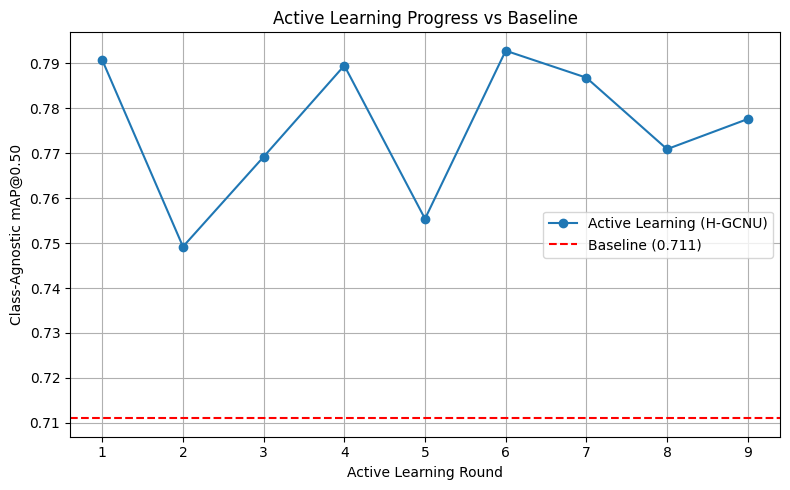

In [8]:
import matplotlib.pyplot as plt

# mAP@0.50 after each round (copied from your logs)
map_values = [
    0.7907,
    0.7492,
    0.7692,
    0.7895,
    0.7554,
    0.7928,
    0.7868,
    0.7709,
    0.7776
]

# Your reported baseline (no AL)
baseline_map = 0.7110

rounds = list(range(1, len(map_values) + 1))

plt.figure(figsize=(8, 5))
plt.plot(rounds, map_values, marker='o', label='Active Learning (H-GCNU)')
plt.axhline(y=baseline_map, color='r', linestyle='--', label=f'Baseline ({baseline_map:.3f})')
plt.xlabel("Active Learning Round")
plt.ylabel("Class-Agnostic mAP@0.50")
plt.title("Active Learning Progress vs Baseline")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


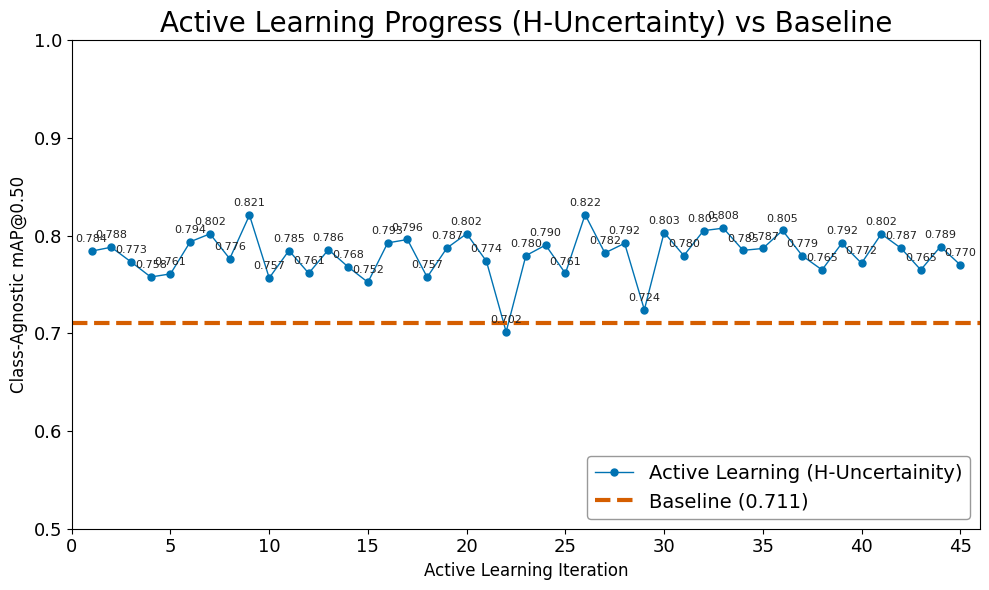

In [27]:
import matplotlib.pyplot as plt

map_values = [
    0.7842, 0.7882, 0.7732, 0.7577, 0.7609, 0.7938, 0.8019, 0.7764, 0.8210, 0.7567,
    0.7848, 0.7615, 0.7857, 0.7680, 0.7523, 0.7926, 0.7961, 0.7575, 0.7874, 0.8020,
    0.7739, 0.7016, 0.7796, 0.7904, 0.7614, 0.8215, 0.7823, 0.7922, 0.7242, 0.8032,
    0.7796, 0.8052, 0.8077, 0.7850, 0.7869, 0.8054, 0.7794, 0.7650, 0.7922, 0.7718,
    0.8018, 0.7872, 0.7650, 0.7889, 0.7701
]
rounds = list(range(1, len(map_values) + 1))
baseline_map = 0.7110

plt.figure(figsize=(10, 6))
plt.plot(rounds, map_values, marker='o', linewidth=1, markersize=5, label='Active Learning (H-Uncertainity)', color="#0072B2")
plt.axhline(y=baseline_map, color='#D55E00', linestyle='--', linewidth=3, label=f'Baseline ({baseline_map:.3f})')

# Annotate each point
for x, y in zip(rounds, map_values):
    plt.text(x, y + 0.007, f"{y:.3f}", ha='center', va='bottom', fontsize=8, color='#222222')

plt.xlim(0, 46)
plt.ylim(0.5, 1.0)
plt.xticks(range(0, 46, 5), fontsize=13)
plt.yticks(fontsize=13)

plt.xlabel("Active Learning Iteration", fontsize=12)
plt.ylabel("Class-Agnostic mAP@0.50", fontsize=12)
plt.title("Active Learning Progress (H-Uncertainty) vs Baseline", fontsize=20)

# plt.grid(alpha=0.25, linestyle=':')
plt.legend(fontsize=14, loc='lower right', frameon=True, facecolor='white', edgecolor='gray')
plt.tight_layout()
plt.savefig("active_learning_progress_h_uncertainty.png", dpi=600, bbox_inches='tight')
plt.show()
